In [1]:
import os
import torch
import matplotlib.pyplot as plt
import numpy as np
from tqdm.notebook import tqdm

import pyro
from pyro.infer import SVI, Trace_ELBO
from pyro.infer.autoguide import AutoNormal
from pyro.optim import Adam, Adagrad
import pyro.distributions as dist
import pyro.optim as optim
import json
from scipy.special import expit

In [2]:

# helpers
def binomial(n_samples, theta_like=0.7, seed=20):
    np.random.seed(seed)
    data = np.random.binomial(n_samples, theta_like)
    return data

def load_config(config_file="config.json"):

    with open(config_file, 'r') as f:
        config = json.load(f)
    return config

def _logistic_normal_mean_std_mc(mu, sigma, n_samples=10_000, seed=0):
    mu = float(np.squeeze(mu))
    sigma = float(np.squeeze(sigma))
    rng = np.random.default_rng(seed)
    z = rng.normal(loc=mu, scale=sigma, size=n_samples)
    theta = expit(z)
    return float(theta.mean()), float(theta.std(ddof=1))

def _trace_locscale_to_theta_moments(loc_trace, scale_trace, n_samples=10_000, seed=0):
    """Batched transformation using torch tensors throughout."""
    loc_trace = torch.as_tensor(loc_trace, dtype=torch.float32)
    scale_trace = torch.as_tensor(scale_trace, dtype=torch.float32)

    T = loc_trace.shape[0]
    batch_size = 5000  # Process 5000 timepoints at once (50M elements = ~200MB)

    out_mean = []
    out_std = []

    generator = torch.Generator()
    generator.manual_seed(seed)

    for start_idx in range(0, T, batch_size):
        end_idx = min(start_idx + batch_size, T)
        batch_loc = loc_trace[start_idx:end_idx]    # (B,)
        batch_scale = scale_trace[start_idx:end_idx]  # (B,)

        z = torch.normal(
            mean=batch_loc[:, None].expand(-1, n_samples),
            std=batch_scale[:, None].expand(-1, n_samples),
            generator=generator,
        )  # (B, n_samples)
        theta = torch.sigmoid(z)  # (B, n_samples)

        out_mean.append(theta.mean(dim=1))
        out_std.append(theta.std(dim=1, correction=1))

    return torch.cat(out_mean).numpy(), torch.cat(out_std).numpy()


def save_rr_tracking_csv(csv_path, trajectory_sets, iterations=None, float_format=".17g"):
    import csv
    import os

    if not isinstance(trajectory_sets, dict):
        trajectory_sets = {"default": trajectory_sets}

    first_n_iters = None
    prepared = {}
    for scenario, trajectories in trajectory_sets.items():
        if len(trajectories) != 4:
            raise ValueError(
                "Each trajectory set must contain "
                "(single_means, single_stds, multi_means, multi_stds)."
            )
        arrays = tuple(np.asarray(traj) for traj in trajectories)
        if any(arr.ndim != 2 for arr in arrays):
            raise ValueError("All random-restart trajectories must be 2D arrays.")
        shapes = {arr.shape for arr in arrays}
        if len(shapes) != 1:
            raise ValueError(
                "All trajectories in a scenario must have matching (restart, iteration) shapes."
            )
        n_iters = arrays[0].shape[1]
        if first_n_iters is None:
            first_n_iters = n_iters
        elif n_iters != first_n_iters:
            raise ValueError("All scenarios must have the same number of iterations.")
        prepared[scenario] = arrays

    if first_n_iters is None:
        raise ValueError("No trajectories were provided.")

    if iterations is None:
        iterations = np.arange(first_n_iters)
    else:
        iterations = np.asarray(iterations)
        if iterations.shape != (first_n_iters,):
            raise ValueError("iterations must have one value per trajectory column.")

    directory = os.path.dirname(os.fspath(csv_path))
    if directory:
        os.makedirs(directory, exist_ok=True)

    labels = (
        ("1", "mean"),
        ("1", "std"),
        ("100", "mean"),
        ("100", "std"),
    )
    with open(csv_path, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(
            ["scenario", "mc_samples", "statistic", "restart"]
            + [format(float(x), float_format) for x in iterations]
        )
        for scenario, arrays in prepared.items():
            for (mc_samples, statistic), values in zip(labels, arrays):
                for restart, row in enumerate(values):
                    writer.writerow(
                        [scenario, mc_samples, statistic, restart]
                        + [format(float(x), float_format) for x in row]
                    )


def load_rr_tracking_csv(csv_path, scenario="default"):
    import csv

    grouped = {}
    with open(csv_path, "r", newline="") as f:
        reader = csv.reader(f)
        header = next(reader)
        if header[:4] != ["scenario", "mc_samples", "statistic", "restart"]:
            raise ValueError("Unexpected random-restart CSV header.")
        x = np.asarray(header[4:], dtype=float)
        for row in reader:
            row_scenario = row[0]
            if scenario is not None and row_scenario != scenario:
                continue
            key = (int(row[1]), row[2])
            grouped.setdefault(key, []).append(
                (int(row[3]), np.asarray(row[4:], dtype=float))
            )

    def stack(mc_samples, statistic):
        key = (mc_samples, statistic)
        if key not in grouped:
            raise ValueError(
                f"No rows found for scenario={scenario!r}, "
                f"mc_samples={mc_samples}, statistic={statistic!r}."
            )
        return np.stack([values for _, values in sorted(grouped[key])], axis=0)

    return (
        stack(1, "mean"),
        stack(1, "std"),
        stack(100, "mean"),
        stack(100, "std"),
        x,
    )

data_gen = binomial


In [3]:
config_file = "../beta_config.json"
config = load_config(config_file)

theta_like = config['theta_like']
alpha_prior = config['alpha_prior']
beta_prior = config['beta_prior']
n_samples = config['n_samples']
max_iters = int(os.environ.get("SIMPLEVI_PYRO_BETA_MAX_ITERS", "1000"))
n_restarts = int(os.environ.get("SIMPLEVI_PYRO_BETA_RESTARTS", "3"))
moment_samples = int(os.environ.get("SIMPLEVI_PYRO_BETA_MOMENT_SAMPLES", "1000"))
reference_samples = int(os.environ.get("SIMPLEVI_PYRO_BETA_REFERENCE_SAMPLES", "5000"))
adam_step = 5e-4 # the "default"

data = data_gen(n_samples) if n_samples > 0 else 0
# print parameters
print("prior: Beta({}, {})".format(alpha_prior, beta_prior))
print("Likelihood: Binomial({})".format(theta_like))
print(data)
print("Random restarts: {} | iterations: {} | moment samples: {}".format(n_restarts, max_iters, moment_samples))
# true_post = beta_posterior(data, n_samples, alpha_prior, beta_prior)
# print("True posterior: Beta({}, {:.2f})".format(true_post['alpha_post'], true_post['beta_post']) + " with mean {:.2f} and std {:.2f}".format(true_post['mean_post'], true_post['std_post']))
# Note that our plots do compare to the "best variational approximation"

prior: Beta(0.5, 0.6)
Likelihood: Binomial(0.7)
7
Random restarts: 3 | iterations: 1000 | moment samples: 1000


In [4]:
def run_restart(seed):
    np.random.seed(seed)

    def single_model(y):
        theta = pyro.sample("theta", dist.Beta(alpha_prior, beta_prior))
        # pyro.sample("obs", dist.Binomial(n_samples, theta), obs=y)
        for i in range(len(y)):
            # observe datapoint i using the likelihood
            pyro.sample("obs_{}".format(i), dist.Binomial(n_samples, theta), obs=y[i])

    def multi_model(y):
        theta = pyro.sample("theta", dist.Beta(alpha_prior, beta_prior))
        # pyro.sample("obs", dist.Binomial(n_samples, theta), obs=y)
        for i in range(len(y)):
            # observe datapoint i using the likelihood
            pyro.sample("obs_{}".format(i), dist.Binomial(n_samples, theta), obs=y[i])

    y_data = []

    def run_svi(y_data, svi_model, samps=1):
        tracker = {
            'mu_loc': np.zeros(max_iters),
            'mu_scale': np.zeros(max_iters)
        }
        # the 0th entry will be incorrect since
        # the guide doesn't store the params in pyro
        # until after the first step is called
        for i in tqdm(range(max_iters), position=0, leave=False, desc="{} MC samples".format(samps)):
            svi_model.step(y_data)
            tracker['mu_loc'][i] = pyro.param("AutoNormal.locs.theta").item()
            tracker['mu_scale'][i] = pyro.param("AutoNormal.scales.theta").item()
        return tracker

    def fit_model(model, num_particles, samps, seed_offset):
        pyro.clear_param_store()
        pyro.set_rng_seed(seed + seed_offset)
        guide = AutoNormal(model)
        optimizer = pyro.optim.Adam({}) # can leave args empty
        elbo = Trace_ELBO(num_particles=num_particles)
        svi = SVI(model, guide, optimizer, elbo)
        return run_svi(y_data, svi, samps=samps)

    single_tracker = fit_model(single_model, num_particles=1, samps=1, seed_offset=0)
    multi_tracker = fit_model(multi_model, num_particles=100, samps=100, seed_offset=10_000)
    return single_tracker, multi_tracker


In [5]:
results = []
for seed in tqdm(range(n_restarts), position=1, desc="Random restarts..."):
    result = run_restart(seed)
    results.append(result)

Random restarts...:   0%|          | 0/3 [00:00<?, ?it/s]

1 MC samples:   0%|          | 0/1000 [00:00<?, ?it/s]

100 MC samples:   0%|          | 0/1000 [00:00<?, ?it/s]

1 MC samples:   0%|          | 0/1000 [00:00<?, ?it/s]

100 MC samples:   0%|          | 0/1000 [00:00<?, ?it/s]

1 MC samples:   0%|          | 0/1000 [00:00<?, ?it/s]

100 MC samples:   0%|          | 0/1000 [00:00<?, ?it/s]

In [6]:
plt.rcParams.update({'font.size': 20})
TRACKING_CSV = "processed_tracking/rr_pyro_beta_tracking.csv"

# ----------------------------
# unpack results -> stacks also transform
# ----------------------------
single_means, single_stds = [], []
multi_means,  multi_stds  = [], []
for single_tracker, multi_tracker in tqdm(results):
    # Use vectorized transformation for speed
    single_mu, single_sigma = _trace_locscale_to_theta_moments(
        single_tracker['mu_loc'], single_tracker['mu_scale'], n_samples=moment_samples, seed=0
    )
    multi_mu, multi_sigma = _trace_locscale_to_theta_moments(
        multi_tracker['mu_loc'], multi_tracker['mu_scale'], n_samples=moment_samples, seed=0
    )
    
    single_means.append(single_mu)
    single_stds.append(single_sigma)
    multi_means.append(multi_mu)
    multi_stds.append(multi_sigma)

single_means = np.stack(single_means, axis=0)  # (N, T)
single_stds  = np.stack(single_stds,  axis=0)  # (N, T)
multi_means  = np.stack(multi_means,  axis=0)  # (N, T)
multi_stds   = np.stack(multi_stds,   axis=0)  # (N, T)

save_rr_tracking_csv(
    TRACKING_CSV,
    {"default": (single_means, single_stds, multi_means, multi_stds)},
)


  0%|          | 0/3 [00:00<?, ?it/s]

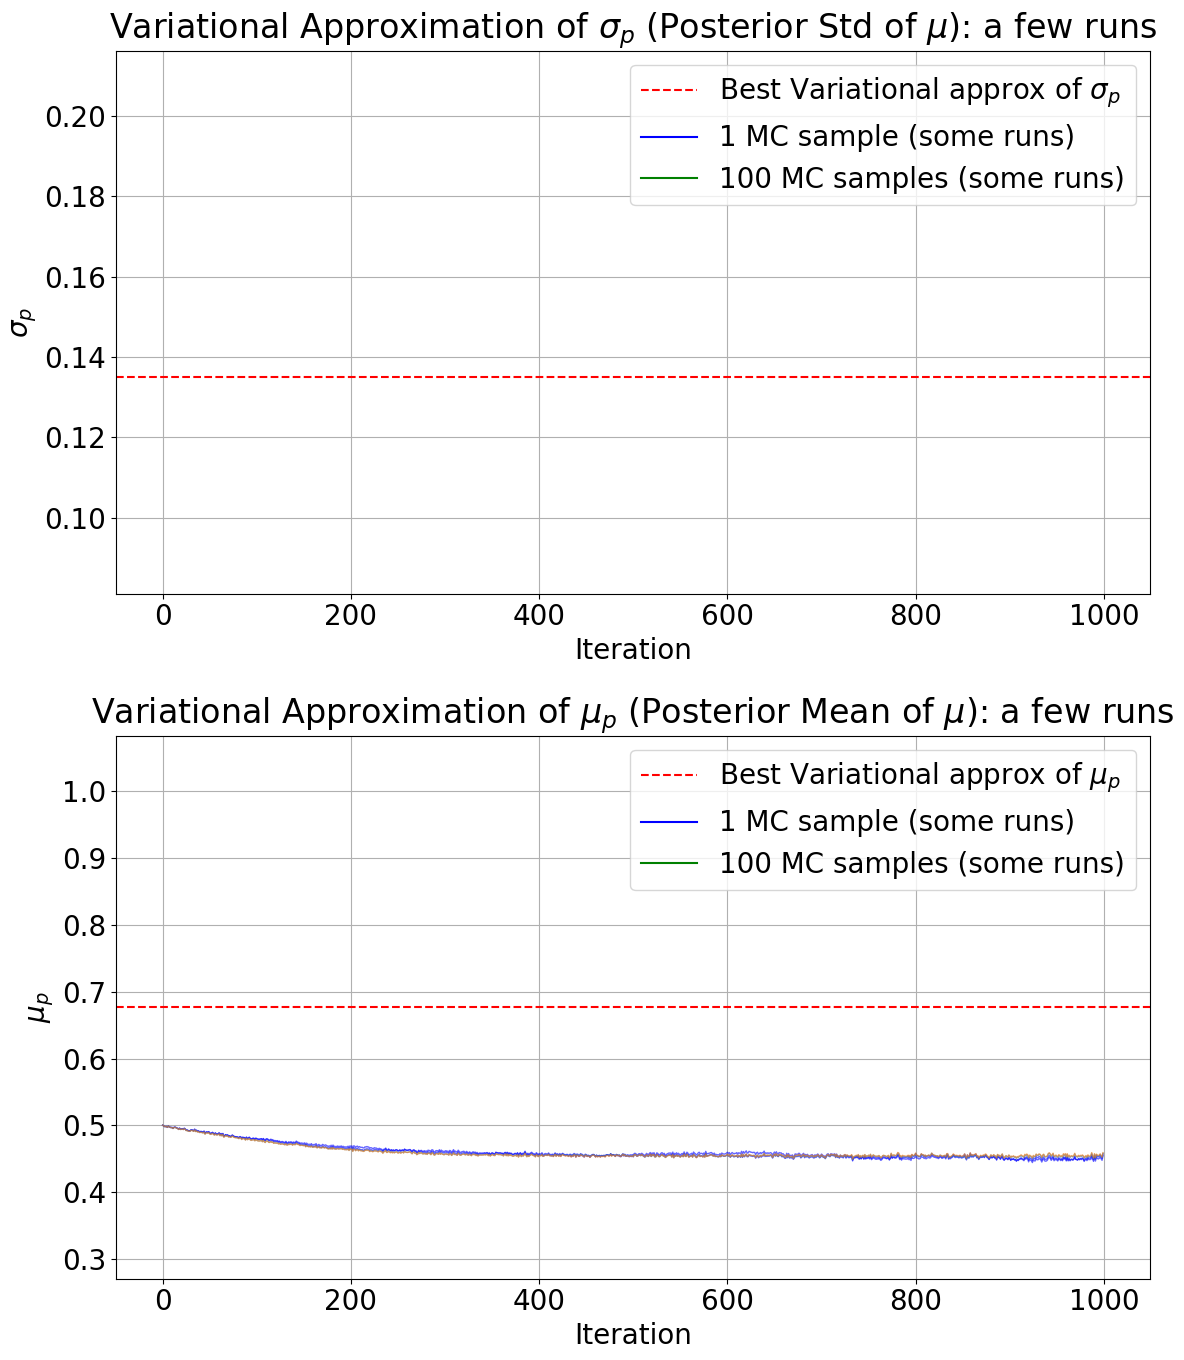

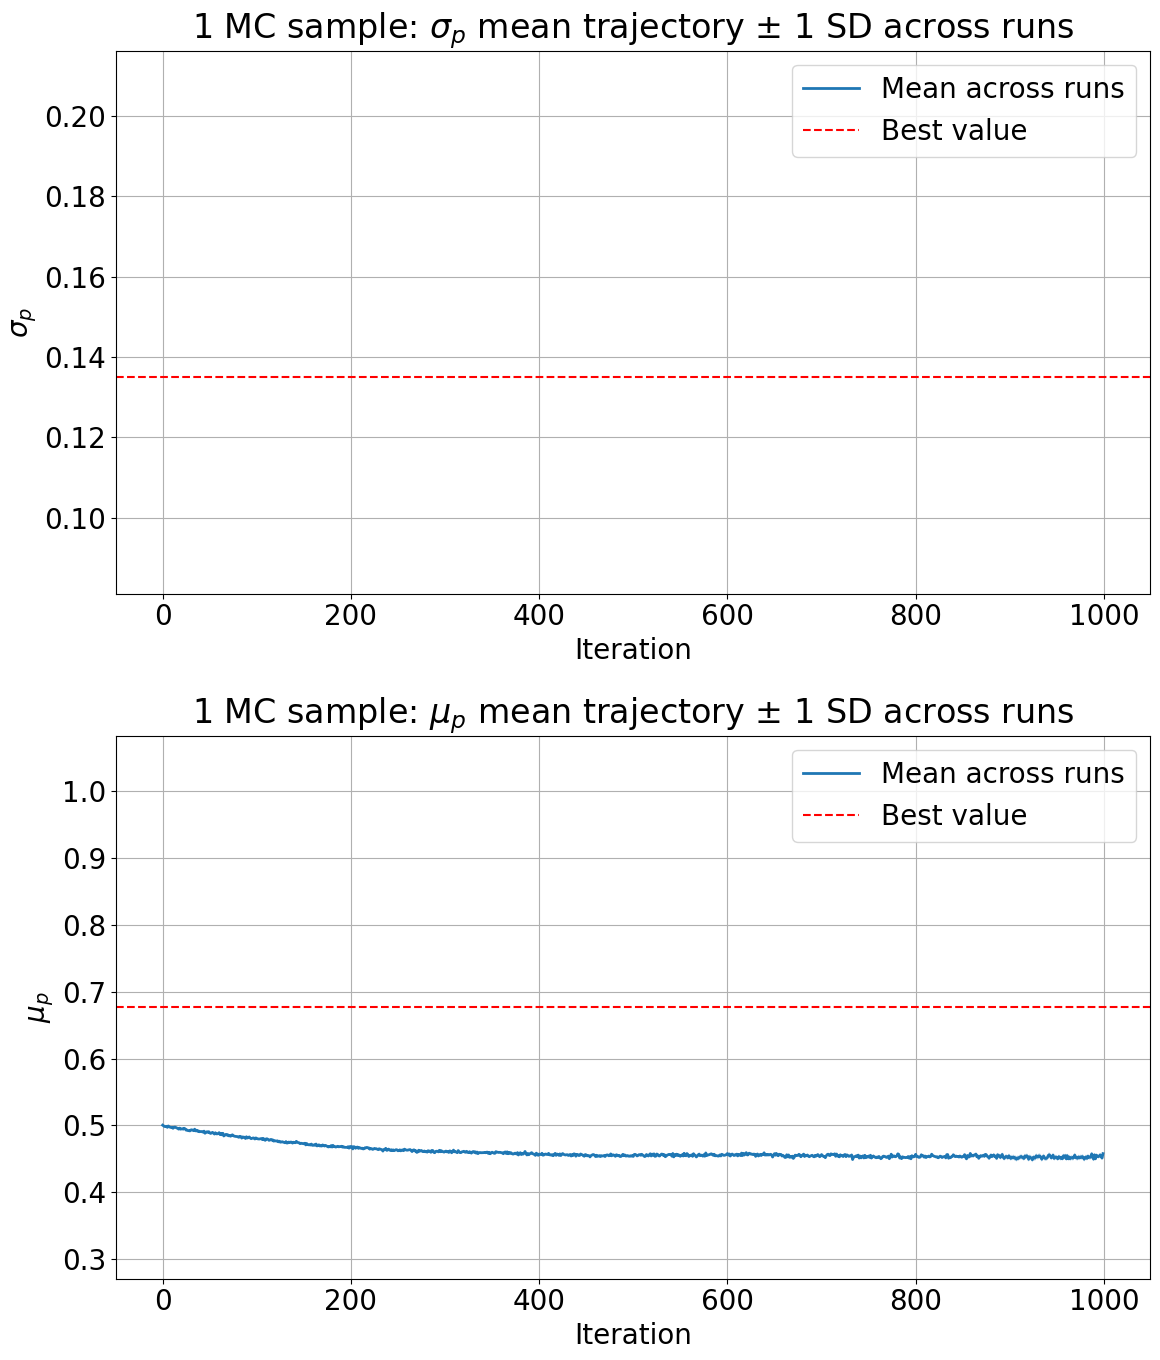

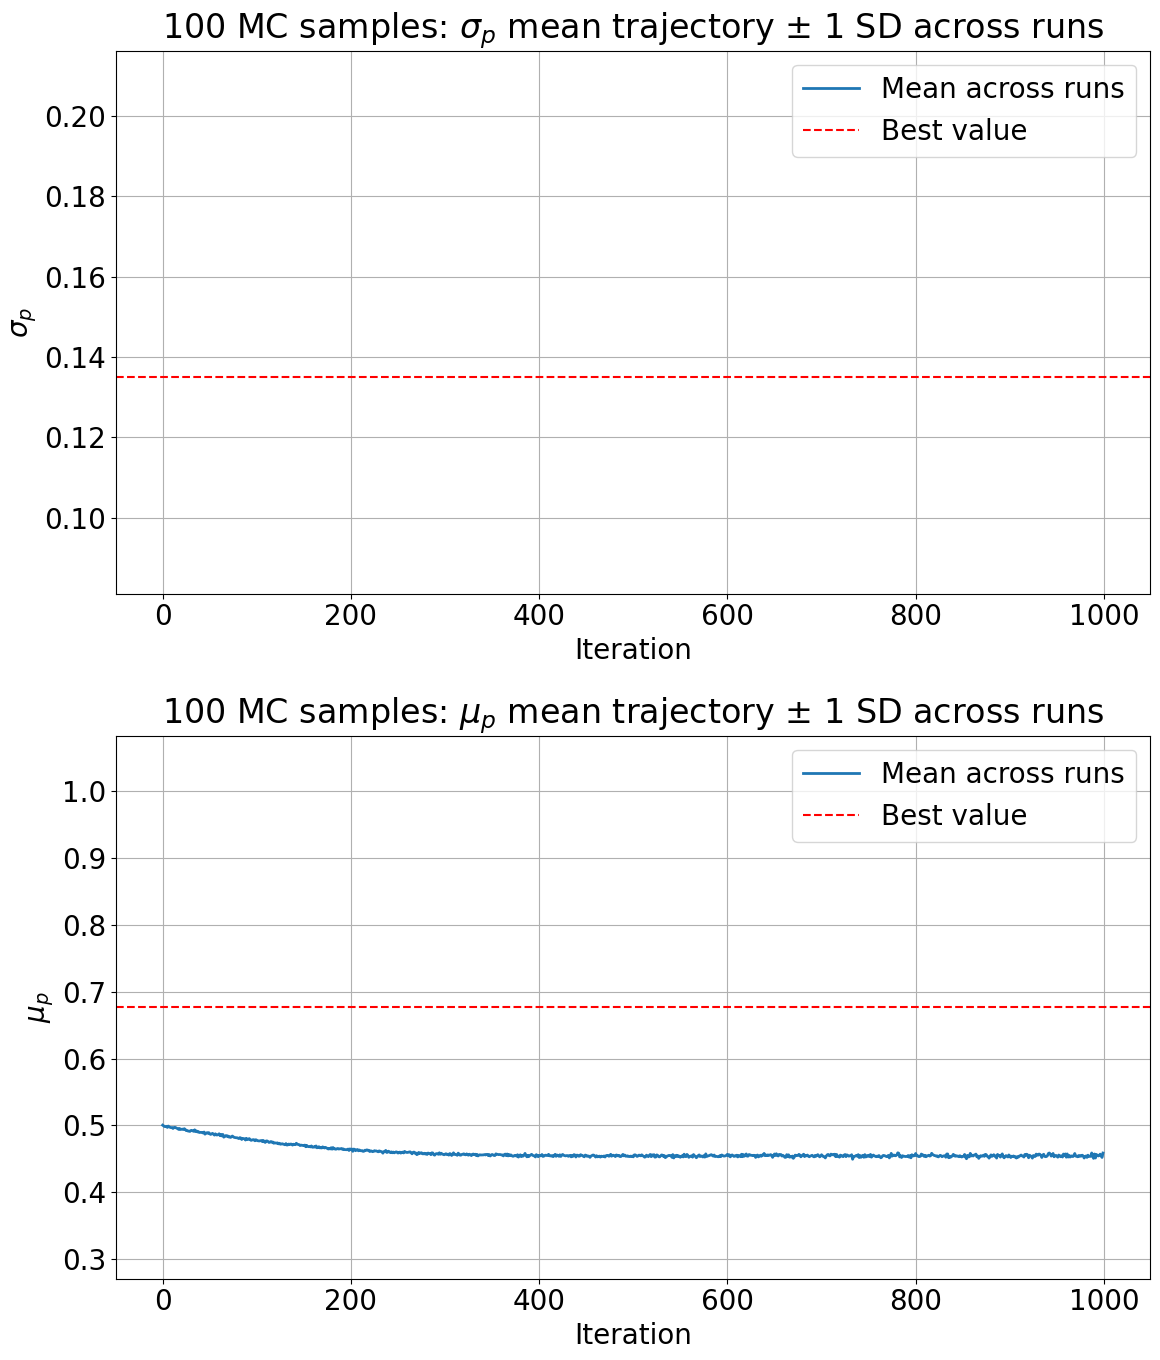

In [7]:
TRACKING_CSV = "processed_tracking/rr_pyro_beta_tracking.csv"

# Re-run this cell to plot from the saved CSV without refitting or reprocessing.
single_means, single_stds, multi_means, multi_stds, x = load_rr_tracking_csv(
    TRACKING_CSV
)
N, T = single_means.shape

# If you have "best" from config, these should be on theta-scale (0,1)
best_mu = float(config["best_mean"]) if "config" in globals() and "best_mean" in config else None
best_std = float(config["best_std"]) if "config" in globals() and "best_std" in config else None
best_mu, best_std = _logistic_normal_mean_std_mc(best_mu, best_std, n_samples=reference_samples, seed=1)
# ----------------------------
# Plot 1: overlay a few trajectories from each condition
# ----------------------------
k = 2  # how many trajectories to show from each
idx = np.linspace(0, N - 1, k, dtype=int)  # deterministic selection

fig, axs = plt.subplots(2, 1, figsize=(12, 14))

# std of mu
for i in idx:
    axs[0].plot(x, single_stds[i], alpha=0.6, linewidth=1, color='blue')
for i in idx:
    axs[0].plot(x, multi_stds[i],  alpha=0.6, linewidth=1, color='green')

axs[0].axhline(best_std, color='red', linestyle='--', label=r'Best Variational approx of $\sigma_p$')
axs[0].set_title(r'Variational Approximation of $\sigma_p$ (Posterior Std of $\mu$): a few runs')
axs[0].set_xlabel('Iteration')
axs[0].set_ylabel(r'$\sigma_p$')
axs[0].grid()
axs[0].set_ylim(best_std * 0.6, best_std * 1.6)

# mean of mu
for i in idx:
    axs[1].plot(x, single_means[i], alpha=0.6, linewidth=1, color='blue', label=None)
for i in idx:
    axs[1].plot(x, multi_means[i],  alpha=0.6, linewidth=1, label=None)

axs[1].axhline(best_mu, color='red', linestyle='--', label=r'Best Variational approx of $\mu_p$')
axs[1].set_title(r'Variational Approximation of $\mu_p$ (Posterior Mean of $\mu$): a few runs')
axs[1].set_xlabel('Iteration')
axs[1].set_ylabel(r'$\mu_p$')
axs[1].grid()
axs[1].set_ylim(best_mu - 3 * best_std, best_mu + 3 * best_std)

# manual legend (so we do not get 16 duplicate entries)
axs[0].plot([], [], color='blue', label='1 MC sample (some runs)')
axs[0].plot([], [], color='green', label='100 MC samples (some runs)')
axs[0].legend()

axs[1].plot([], [], color='blue', label='1 MC sample (some runs)')
axs[1].plot([], [], color='green', label='100 MC samples (some runs)')
axs[1].legend()

plt.tight_layout()
plt.show()

# ----------------------------
# Plot 2: mean trajectory +/- 1 std band across runs (separate plots for 1-MC and 100-MC)
# ----------------------------
def plot_mean_band(ax, x, Y, true_value, title, ylabel):
    """
    Y: (N, T) trajectories
    """
    m = Y.mean(axis=0)
    s = Y.std(axis=0)
    ax.plot(x, m, linewidth=2, label='Mean across runs')
    ax.fill_between(x, m - s, m + s, alpha=0.25)
    ax.axhline(true_value, color='red', linestyle='--', label='Best value')
    ax.set_title(title)
    ax.set_xlabel('Iteration')
    ax.set_ylabel(ylabel)
    ax.grid()
    ax.legend()

# 1 MC sample: mean +/- sd across runs
fig, axs = plt.subplots(2, 1, figsize=(12, 14))
plot_mean_band(
    axs[0], x, single_stds, best_std,
    r'1 MC sample: $\sigma_p$ mean trajectory $\pm$ 1 SD across runs',
    r'$\sigma_p$'
)
axs[0].set_ylim(best_std * 0.6, best_std * 1.6)

plot_mean_band(
    axs[1], x, single_means, best_mu,
    r'1 MC sample: $\mu_p$ mean trajectory $\pm$ 1 SD across runs',
    r'$\mu_p$'
)
axs[1].set_ylim(best_mu - 3 * best_std, best_mu + 3 * best_std)

plt.tight_layout()
plt.show()

# 100 MC samples: mean +/- sd across runs
fig, axs = plt.subplots(2, 1, figsize=(12, 14))
plot_mean_band(
    axs[0], x, multi_stds, best_std,
    r'100 MC samples: $\sigma_p$ mean trajectory $\pm$ 1 SD across runs',
    r'$\sigma_p$'
)
axs[0].set_ylim(best_std * 0.6, best_std * 1.6)

plot_mean_band(
    axs[1], x, multi_means, best_mu,
    r'100 MC samples: $\mu_p$ mean trajectory $\pm$ 1 SD across runs',
    r'$\mu_p$'
)
axs[1].set_ylim(best_mu - 3 * best_std, best_mu + 3 * best_std)

plt.tight_layout()
plt.show()


In [8]:
for i in pyro.get_param_store():
    print(i)

AutoNormal.locs.theta
AutoNormal.scales.theta
